In [10]:
!wget -nc https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2026-03-13 15:20:54--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-03-13 15:20:54 ERROR 403: Forbidden.



In [2]:
from transformers import pipeline

In [3]:
import pandas as pd
import numpy as np
import torch

In [4]:
torch.cuda.is_available()

True

In [6]:
torch.cuda.current_device()

0

In [7]:
# featurizer = pipeline("feature-extraction") # if processor only
featurizer = pipeline("feature-extraction", device=0) # if gpu

No model was supplied, defaulted to distilbert/distilbert-base-cased and revision 6ea8117.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert/distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
df = pd.read_csv("bbc_text_cls.csv")

In [ ]:
df.head()

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


In [12]:
df.shape

(2225, 2)

In [13]:
result = featurizer(df.iloc[0].text)

Token indices sequence length is longer than the specified maximum sequence length for this model (588 > 512). Running this sequence through the model will result in indexing errors


RuntimeError: The size of tensor a (588) must match the size of tensor b (512) at non-singleton dimension 1

In [14]:
result = featurizer(' '.join(df.iloc[0].text.split()[:350]))

In [15]:
print(result)

[[[0.34180551767349243, -0.062317781150341034, -0.16504672169685364, -0.1547003835439682, -0.11870723962783813, -0.0017884799744933844, 0.3673284351825714, -0.13412772119045258, 0.02235514298081398, -0.9997072815895081, 0.004415746312588453, -0.0020089743193238974, -0.015548652969300747, -0.17251884937286377, -0.45215702056884766, 0.17105156183242798, 0.07629382610321045, -0.061490967869758606, -0.17123638093471527, -0.1941695362329483, 0.030757511034607887, -0.14906924962997437, 0.6698344349861145, -0.38120245933532715, 0.17754778265953064, 0.25015416741371155, 0.026368312537670135, 0.2597676217556, -0.2915778160095215, 0.34694719314575195, -0.14456214010715485, 0.2537398040294647, 0.003653548425063491, -0.08672090619802475, -0.08170763403177261, 0.023386720567941666, 0.015332397073507309, -0.454850971698761, -0.07963751256465912, -0.1950358897447586, -0.43590956926345825, 0.1831987351179123, 0.5221923589706421, -0.2178674042224884, 0.06131255626678467, -0.38974758982658386, -0.011442

In [16]:
type(result)

list

In [17]:
len(result)

1

In [19]:
len(result[0])

504

In [20]:
len(result[0][0])

768

In [22]:
result[0][0][0]

0.34180551767349243

In [18]:
r_np = np.array(result)
r_np.shape

(1, 504, 768)

In [21]:
results = featurizer([' '.join(text.split()[:350]) for text in df.iloc[:5].text])

In [23]:
len(results)

5

In [24]:
np.array(results[0]).shape

(1, 504, 768)

In [25]:
np.array(results[1]).shape

(1, 442, 768)

In [26]:
np.array(results[2]).shape

(1, 372, 768)

In [27]:
len(df.iloc[0].text.split())

421

In [28]:
len(df.iloc[1].text.split())

384

In [29]:
len(df.iloc[2].text.split())

264

In [30]:
lens = [len(a.split()) for a in df.text]

In [31]:
lens[:5]

[421, 384, 264, 406, 265]

4432


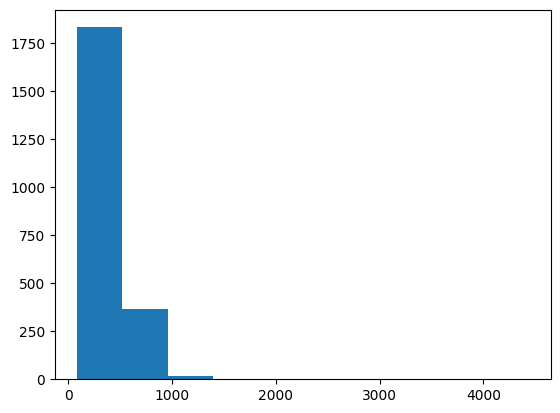

In [32]:
import matplotlib.pyplot as plt

plt.hist(lens)
print(np.max(lens))

In [33]:
texts = [' '.join(a.split()[:100]) for a in df.text]

In [34]:
embeddings = featurizer(texts)

In [35]:
# list of N elements, each element is 1 x T x D with a variable T
# We want to keep only the first embedding vector (due to how transformers work)
# embeddings = [np.array(e[0]).mean(axis=0) for e in embeddings] # average
embeddings = [e[0][0] for e in embeddings] # first

In [36]:
embeddings = np.array(embeddings)
embeddings.shape

(2225, 768)

In [37]:
from sklearn.neighbors import NearestNeighbors

In [38]:
model = NearestNeighbors(metric='cosine')
model.fit(embeddings)

NearestNeighbors(metric='cosine')

In [39]:
distances, indices = model.kneighbors(embeddings[10].reshape(1, -1))

In [40]:
distances

array([[1.11022302e-16, 7.08888981e-03, 8.23364501e-03, 9.57619874e-03,
        1.04166748e-02]])

In [41]:
indices

array([[  10,    0,  273, 2160,  279]])

In [43]:
df.iloc[10].text

"Ask Jeeves tips online ad revival\n\nAsk Jeeves has become the third leading online search firm this week to thank a revival in internet advertising for improving fortunes.\n\nThe firm's revenue nearly tripled in the fourth quarter of 2004, exceeding $86m (£46m). Ask Jeeves, once among the best-known names on the web, is now a relatively modest player. Its $17m profit for the quarter was dwarfed by the $204m announced by rival Google earlier in the week. During the same quarter, Yahoo earned $187m, again tipping a resurgence in online advertising.\n\nThe trend has taken hold relatively quickly. Late last year, marketing company Doubleclick, one of the leading providers of online advertising, warned that some or all of its business would have to be put up for sale. But on Thursday, it announced that a sharp turnaround had brought about an unexpected increase in profits. Neither Ask Jeeves nor Doubleclick thrilled investors with their profit news, however. In both cases, their shares fe

In [44]:
df.iloc[10].labels

'business'

In [45]:
df.iloc[0].text

'Ad sales boost Time Warner profit\n\nQuarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.\n\nThe firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.\n\nTime Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL\'s underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sig

In [49]:
df.iloc[0].labels

'business'

In [47]:
df.iloc[273].text

"Google shares fall as staff sell\n\nShares in Google have fallen 6.7% after employees and early investors in the web search took advantage of the first chance to sell their holdings.\n\nRestrictions were imposed ahead of its flotation in August, to prevent shares being dumped quickly onto the market. In one of the most closely-watched initial public offerings in stock market history, the US-based company sold 19.6 million shares at $85 each. Google shares have risen since but fell $12.33 on Tuesday to close at $172.55. The restriction - known as a lockup - is being eased piecemeal: in all, some 227 million additional shares will become free to trade by February 2005. Selling the shares could turn many of Google's workers into millionaires.\n\nThere were fears that the potential increase of shares in circulation from Tuesday would ease demand for stock. However, analysts say they expected most shareholders would be holding back from selling all their shares immediately, as Google's goo

In [50]:
df.iloc[273].labels

'business'

In [51]:
df.iloc[2160].text

'Can Yahoo dominate next decade?\n\nYahoo has reached the grand old age of 10 and, in internet years, that is a long time.\n\nFor many, Yahoo remains synonymous with the internet - a veteran that managed to ride the dot-com wave and the subsequent crash and maintain itself as one of the web\'s top brands. But for others there is another, newer net icon threatening to overshadow Yahoo in the post dot-com world - Google.\n\nThe veteran and the upstart have plenty in common - Yahoo was the first internet firm to offer initial public shares and Google was arguably the most watched IPO (Initial Public Offering) of the post-dot-com era. Both began life as search engines although in 2000, when Yahoo chose Google to power its search facility while it concentrated on its web portal business, it was very much Yahoo that commanded press attention. In recent years, the column inches have stacked up in Google\'s favour as the search engine also diversifies with the launch of services such as Gmail,

In [52]:
df.iloc[2160].labels

'tech'

In [53]:
df.iloc[279].text

'Amex shares up on spin-off news\n\nShares in American Express surged more than 8% on Tuesday after it said it was to spin off its less profitable financial advisory subsidiary.\n\nThe US credit card to travel services giant said off-loading American Express Financial Advisors (AEFA) would boost its profitability. AEFA has more than 12,000 advisers selling financial advice, funds and insurance to 2.5 million customers. Over the years it has delivered poor profits and even some losses.\n\n"This is an excellent move by American Express to focus on its core businesses, and sell off a laggard division, which has been a problem for quite some time," said Marquis Investment Research analyst Phil Kain. Analysts estimate that a stand-alone AEFA could have a market value of $10bn (£5.3bn). The unit was acquired by American Express 20 years ago as Investors Diversified Service, of Minneapolis, at a time when firms were amassing one-stop financial empires. However, the business of selling investm

In [54]:
df.iloc[279].labels

'business'

In [55]:
query = featurizer("TV and film")

In [56]:
len(query)

1

In [57]:
len(query[0])

5

In [58]:
len(query[0][0])

768

In [59]:
distances, indices = model.kneighbors(np.array(query[0][0]).reshape(1, -1))

In [60]:
distances

array([[0.02692949, 0.02692949, 0.02718367, 0.02872824, 0.02919898]])

In [61]:
indices

array([[2136, 1917,  846, 2183,  606]])

In [63]:
df.iloc[2136].text

'What high-definition will do to DVDs\n\nFirst it was the humble home video, then it was the DVD, and now Hollywood is preparing for the next revolution in home entertainment - high-definition.\n\nHigh-definition gives incredible, 3D-like pictures and surround sound. The DVD disks and the gear to play them will not be out for another year or so, and there at are still a number of issues to be sorted out. But when high-definition films do come out on the new format DVDs, it will profoundly change home entertainment. For Rick Dean, director of business development for digital content company THX, a high-definition future is an exciting prospect. He has worked on the Star Wars DVD trilogy, Finding Nemo, The Incredibles and Indiana Jones. "There was a time not so long ago when the film world and the video world were two completely separate worlds," he told the BBC News website.\n\n"The technology we are dealing with now means they are very much conjoined. "The film that we see in theatres 

In [64]:
df.iloc[2136].labels

'tech'

In [65]:
df.iloc[1917].text

'What high-definition will do to DVDs\n\nFirst it was the humble home video, then it was the DVD, and now Hollywood is preparing for the next revolution in home entertainment - high-definition.\n\nHigh-definition gives incredible, 3D-like pictures and surround sound. The DVD disks and the gear to play them will not be out for another year or so, and there at are still a number of issues to be sorted out. But when high-definition films do come out on the new format DVDs, it will profoundly change home entertainment. For Rick Dean, director of business development for digital content company THX, a high-definition future is an exciting prospect. He has worked on the Star Wars DVD trilogy, Finding Nemo, The Incredibles and Indiana Jones. "There was a time not so long ago when the film world and the video world were two completely separate worlds," he told the BBC News website.\n\n"The technology we are dealing with now means they are very much conjoined. "The film that we see in theatres 

In [67]:
df.iloc[1917].labels

'tech'

In [68]:
# odd they're the same article
df.iloc[846].text

'Career honour for actor DiCaprio\n\nActor Leonardo DiCaprio\'s "exceptional career" has been honoured at the Santa Barbara International Film Festival.\n\nThe star was presented with the award by Martin Scorsese, who directed him in Oscar-nominated movie The Aviator. "It\'s a lifetime achievement award, which is completely and utterly surreal, given I\'m only 30 years old," DiCaprio said. "But what has it been? Almost 17 years now. I\'ve done quite a few films." A retrospective of his movies was shown.\n\n"What\'s really exciting, for me, is that this is what I really love doing," he added. "It\'s what I want to do for the rest of my life." DiCaprio began his movie career in horror film Critters 3, before moving onto roles in The Basketball Diaries, Romeo and Juliet, Titanic and Gangs of New York. The achievement award was created to commemorate the California festival\'s 20th anniversary and coincided with DiCaprio\'s portrayal of millionaire Howard Hughes in The Aviator.\n\nVeteran 

In [70]:
df.iloc[846].labels

'entertainment'

In [71]:
df.iloc[2183].text

'Confusion over high-definition TV\n\nNow that a critical mass of people have embraced digital TV, DVDs, and digital video recorders, the next revolution for TV is being prepared for our sets.\n\nIn most corners of TV and technology industries, high-definition (HDTV) is being heralded as the biggest thing to happen to the television since colour. HD essentially makes TV picture quality at least four times better than now. But there is real concern that people are not getting the right information about HD on the High Street. Thousands of flat panel screens - LCDs (liquid crystal displays), plasma screens, and DLP rear-projection TV sets - have already been sold as "HD", but are in fact not able to display HD.\n\n"The UK is the largest display market in Europe," according to John Binks, director of GfK, which monitors global consumer markets.\n\nBut, he added: "Of all the flat panel screens sold, just 1.3% in the UK are capable of getting high-definition." There are 74 different devices

In [72]:
df.iloc[2183].labels

'tech'

In [73]:
df.iloc[606].text

'Surprise win for anti-Bush film\n\nMichael Moore\'s anti-Bush documentary Fahrenheit 9/11 has won best film at the US People\'s Choice Awards, voted for by the US public.\n\nMel Gibson\'s The Passion of the Christ won best drama, despite both films being snubbed so far at US film awards in the run-up to February\'s Oscars. Julia Roberts won her 10th consecutive crown as favourite female movie star. Johnny Depp was favourite male movie star and Renee Zellweger was favourite leading lady at Sunday\'s awards in LA.\n\nFilm sequel Shrek 2 took three prizes - voted top animated movie, top film comedy and top sequel. In television categories, Desperate Housewives was named top new drama and Joey, starring former Friends actor Matt LeBlanc, was best new comedy. Long-running shows Will and Grace and CSI: Crime Scene Investigation were named best TV comedy and TV drama respectively.\n\nNominees for the People\'s Choice Awards were picked by a 6,000-strong Entertainment Weekly magazine panel, a

In [74]:
df.iloc[606].labels

'entertainment'